## Script: Multimodal Targeted Recaptioning of Images Before Translation

#### For an input image and English caption, rewrite the English caption with inspiration from Japanese captions belonging to similar images

### Define Variables

In [1]:
# Control flow variables 
MODE = "TGT_RECAP"                                                                    # to mark output name
LOAD_IN_PROGRESS_LLAMA_DICT = False                                                   # to repeat where inference was paused
PATH_TO_GUIDE_PROMPT = "../prompts/tgt_prompt_template.txt"                           # prompt to use
TRAIN_TO_REF_IDX_FILE_PATH = '../data/img_similarities_bw_train_and_ref.pkl'          # img similarities to use
EXAMPLE_FORMAT = "Example:\n\tInput: {inp}\n\tOutput: {out}\n"                        # how to format reference example
OUT_PATH = '../output/' + MODE + '_llama_responses_' + PATH_TO_GUIDE_PROMPT.split('/')[-1][:-4] + '.pkl'         # out path

# Data variables
# There is a training set of English images/captions to be "recaptioned" before translation
# There is a reference set of paired images/captions written from En and Ja speakers
# Ja captions have been translated to English with Google Translate
# NOTE: The id paths will need edited to refer to image locations used for COCO dataset 
TRAIN_IDS = '../data/ids_train.en1'
TRAIN_CAPS = '../data/caps_train.en1'
ALL_EN_REF_IDS = ['../data/ids_ref.en1','../data/ids_ref.en2','../data/ids_ref.en3','../data/ids_ref.en4','../data/ids_ref.en5']
ALL_EN_REF_CAPS = ['../data/caps_ref.en1','../data/caps_ref.en2','../data/caps_ref.en3','../data/caps_ref.en4','../data/caps_ref.en5']
ALL_JA_REF_IDS = ['../data/ids_ref.ja1','../data/ids_ref.ja2','../data/ids_ref.ja3','../data/ids_ref.ja4','../data/ids_ref.ja5']
ALL_JA_REF_CAPS = ['../data/caps_ref.ja_to_en1','../data/caps_ref.ja_to_en2','../data/caps_ref.ja_to_en3','../data/caps_ref.ja_to_en4','../data/caps_ref.ja_to_en5']

# Model info
MODEL_TO_USE = "meta-llama/Llama-3.2-11B-Vision-Instruct"          
PATH_TO_HUGGING_FACE_KEY = '/ihome/akovashka/krb115/hf_key'

# LLM Main params
GPU_MEMORY_UTILIZATION = 0.90 
MAX_MODEL_LEN = 9192 
ENFORCE_EAGER = True
MAXS_NUM_SEQS = 20
MAX_NUMBER_BATCHED_TOKENS = 9192

# LLM Sample params
TEMPERATURE = 0 
SEED = 42
STOP_STRING = "</final>" 
INCLUDE_STOP_STR_IN_OUTPUT = True
MAX_TOKENS = 448
TENSOR_PARALLEL_SIZE = 1

### Imports

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle
from PIL import Image
import random
import torch
from transformers import MllamaForConditionalGeneration, AutoProcessor

random.seed(42)

In [3]:
# GPU-based imports
from vllm import LLM, SamplingParams
from huggingface_hub import login

with open(PATH_TO_HUGGING_FACE_KEY, 'r') as f:
    hf_tok = f.readlines()[0].strip()
login(hf_tok)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /ihome/akovashka/krb115/.cache/huggingface/token
Login successful


### Load training/reference image ids and captions; mention data

In [4]:
ja_ref_idx_to_cap_dict = dict()
en_ref_idx_to_cap_dict = dict()
train_idx_to_cap_dict = dict()

# Assign id to each ref speaker set i = 1 to 5 
for i in range(1,len(ALL_EN_REF_IDS) + 1):
    ja_ref_idx_to_cap_dict[i] = dict()
    en_ref_idx_to_cap_dict[i] = dict()

# Go through each ref path for En and create mapping dictionary
for i, (ref_cap_path, ref_id_path) in enumerate(zip(ALL_EN_REF_CAPS, ALL_EN_REF_IDS)): 
    print(i+1)
    print(ref_cap_path)
    print(ref_id_path)

    with open(ref_cap_path, 'r') as f:
        with open(ref_id_path, 'r') as g:
            en_ref_caps = [l.strip() for l in f.readlines()]
            en_ref_ids = [l.strip() for l in g.readlines()]
            for idx, cap in zip(en_ref_ids, en_ref_caps):
                en_ref_idx_to_cap_dict[i+1][idx] = cap

# Go through each ref path for Ja and create mapping dictionary
for i, (ref_cap_path, ref_id_path) in enumerate(zip(ALL_JA_REF_CAPS, ALL_JA_REF_IDS)): 
    print(i+1)
    print(ref_cap_path)
    print(ref_id_path)

    with open(ref_cap_path, 'r') as f:
        with open(ref_id_path, 'r') as g:
            ja_ref_caps = [l.strip() for l in f.readlines()]
            ja_ref_ids = [l.strip() for l in g.readlines()]
            for idx, cap in zip(ja_ref_ids, ja_ref_caps):
                ja_ref_idx_to_cap_dict[i+1][idx] = cap

# Get train dictionary
with open(TRAIN_CAPS, 'r') as f:
    with open(TRAIN_IDS, 'r') as g:
        train_caps = [l.strip() for l in f.readlines()]
        train_ids = [l.strip() for l in g.readlines()]
        for idx, cap in zip(train_ids, train_caps):
            train_idx_to_cap_dict[idx] = cap

print('Lengths')
print('# Ja Ref Caps: ' + str(len(ja_ref_caps)))
print('# En Ref Caps: ' + str(len(en_ref_caps)))
print('# En Train Caps: ' + str(len(train_caps)))

1
../data/caps_ref.en1
../data/ids_ref.en1
2
../data/caps_ref.en2
../data/ids_ref.en2
3
../data/caps_ref.en3
../data/ids_ref.en3
4
../data/caps_ref.en4
../data/ids_ref.en4
5
../data/caps_ref.en5
../data/ids_ref.en5
1
../data/caps_ref.ja_to_en1
../data/ids_ref.ja1
2
../data/caps_ref.ja_to_en2
../data/ids_ref.ja2
3
../data/caps_ref.ja_to_en3
../data/ids_ref.ja3
4
../data/caps_ref.ja_to_en4
../data/ids_ref.ja4
5
../data/caps_ref.ja_to_en5
../data/ids_ref.ja5
Lengths
# Ja Ref Caps: 9666
# En Ref Caps: 9666
# En Train Caps: 73117


### For each train image, format reference examples into prompt format

In [5]:
# For each image, this is a sorted list of the most similar images (up to 32 examples) 
with open(TRAIN_TO_REF_IDX_FILE_PATH, 'rb') as f:
    train_idx_to_ja_ref_idx = pickle.load(f)

# Format prompts with reference examples
train_idx_to_formatted_prompt = dict()

# For each train image, get reference captions 
for i, idx in enumerate(train_idx_to_ja_ref_idx):

    # Choose random speaker set to use for each image
    random_en_index = random.choice(range(len(ALL_JA_REF_CAPS))) + 1
    random_ja_index = random.choice(range(len(ALL_JA_REF_CAPS))) + 1
    
    # Get reference caps of most similar image to the train 
    ja_ref_idx = train_idx_to_ja_ref_idx[idx][0]
    ja_ref_cap = ja_ref_idx_to_cap_dict[random_ja_index][ja_ref_idx]
    en_ref_cap = en_ref_idx_to_cap_dict[random_en_index][ja_ref_idx]
    train_idx_to_formatted_prompt[idx] = EXAMPLE_FORMAT.format(inp=en_ref_cap, out=ja_ref_cap)
print(train_idx_to_formatted_prompt[idx])

Example:
	Input: Assortment of craft like items on cardboard  on floor.
	Output: Tools lined up on cardboard



### Load guidance prompt

In [6]:
with open(PATH_TO_GUIDE_PROMPT, "r") as f:
    guidance_prompt = "".join(f.readlines())
print(guidance_prompt)

Task Description: For an input image, image caption, and reference input-output caption(s) for similar image(s), rewrite the image caption with similar changes to the style, level of detail, and object term ones made for similar objects in the reference examples. Only perform changes that are correct and semantically relevant to the given input image. After "Output: ", always output a <final> tag, followed by a rewritten caption, then </final>. Never any other text or explanation. One task demo for formatting and change instruction is provided. 

Task Demo:

Reference example(s)
Input: A catcher catching a ball that has just gone by the hitter.
Output: The batter in the orange uniform just missed the ball. 

Inference
Input: A young boy holding a baseball bat during a baseball game.
Output: <final> The batter in the grey uniform is waiting for a ball during a game. </final>

Now perform the task exactly as above:

Reference example(s)
{reference_examples}

Inference
Input: {input} 
Out

### Generate list of prompts

In [7]:
# Format into lists of prompts and corresponding train images 
prompts = []
image_paths = []
for idx in train_idx_to_cap_dict:
    cap = train_idx_to_cap_dict[idx] 
    prompt = guidance_prompt.format(reference_examples=train_idx_to_formatted_prompt[idx], input=cap)
    prompts.append(prompt)
    image_paths.append(idx)

### Define parsing helper

In [8]:
def extract_text_between_final_tags_v2(text):
	start_tag = '<final>'
	end_tag = '</final>'
	start_index = text.find(start_tag)
	if start_index == -1:
		return None
	end_index = text.find(end_tag, start_index)
	if end_index == -1:
		return None
	start_index += len(start_tag)
	return text[start_index:end_index].strip()

### Load model

In [9]:
llm = LLM(
        model=MODEL_TO_USE,
        max_model_len=MAX_MODEL_LEN,
        max_num_seqs=MAXS_NUM_SEQS,
        enforce_eager=INCLUDE_STOP_STR_IN_OUTPUT
    )
sampling_params = SamplingParams(temperature=TEMPERATURE, seed=SEED, stop=STOP_STRING, include_stop_str_in_output=INCLUDE_STOP_STR_IN_OUTPUT, max_tokens=MAX_TOKENS)

WARNING 05-10 12:25:38 config.py:503] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 05-10 12:25:38 llm_engine.py:249] Initializing an LLM engine (v0.6.4) with config: model='meta-llama/Llama-3.2-11B-Vision-Instruct', speculative_config=None, tokenizer='meta-llama/Llama-3.2-11B-Vision-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=9192, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_exec

[W510 12:25:39.754470990 socket.cpp:752] [c10d] The client socket cannot be initialized to connect to [gpu-n55.crc.pitt.edu]:41349 (errno: 97 - Address family not supported by protocol).


INFO 05-10 12:25:40 weight_utils.py:243] Using model weights format ['*.safetensors']


Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]


INFO 05-10 12:26:04 model_runner.py:1077] Loading model weights took 19.9073 GB
INFO 05-10 12:26:04 enc_dec_model_runner.py:277] Starting profile run for multi-modal models.
INFO 05-10 12:26:10 worker.py:232] Memory profiling results: total_gpu_memory=44.39GiB initial_memory_usage=20.56GiB peak_torch_memory=29.38GiB memory_usage_post_profile=20.58Gib non_torch_memory=0.67GiB kv_cache_size=9.90GiB gpu_memory_utilization=0.90
INFO 05-10 12:26:11 gpu_executor.py:113] # GPU blocks: 4056, # CPU blocks: 1638
INFO 05-10 12:26:11 gpu_executor.py:117] Maximum concurrency for 9192 tokens per request: 7.06x


### Test run a batch for inference (helpful for debug) 

In [10]:
BATCH_SIZE = 8

# this is just a test run 
for i in range(0, len(prompts), BATCH_SIZE):
    curr_text_prompts = prompts[i:i+BATCH_SIZE]
    curr_img_paths = image_paths[i:i+BATCH_SIZE]
    curr_imgs = [Image.open(im_path) for im_path in curr_img_paths]
    curr_text_prompts_formatted = [f"<|image|><|begin_of_text|>" + j for j in curr_text_prompts]
    inputs = []
    for j in range(len(curr_imgs)):
        inputs.append({"prompt": curr_text_prompts_formatted[j], 
                        "multi_modal_data": {
                            "image": curr_imgs[j]
                        }, 
                      })
    outputs = llm.generate(inputs, sampling_params=sampling_params)
    break

INFO 05-10 12:26:13 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
WARNING 05-10 12:26:13 preprocess.py:83] Falling back on <BOS> for decoder start token id because decoder start token id is not available.
INFO 05-10 12:26:13 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
INFO 05-10 12:26:13 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
INFO 05-10 12:26:13 preprocess.py:215] Your model u

Processed prompts: 100%|██████████| 8/8 [00:02<00:00,  2.77it/s, est. speed input: 689.63 toks/s, output: 48.10 toks/s]


Index: 0
Ref: Example:
	Input: People shop in an open air market with lots of fruit.
	Output: A bunch of bananas hanging from a string

Input: People shopping in an open market for vegetables.
Output: <final> A pile of carrots on a table in an open air market. </final>


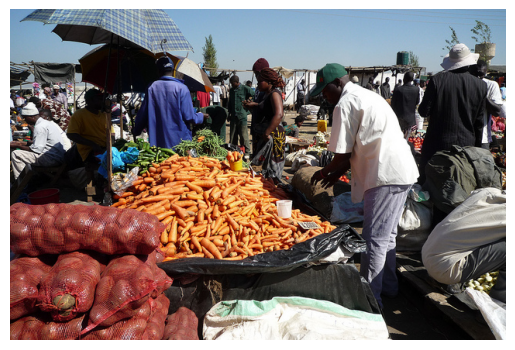

Index: 1
Ref: Example:
	Input: A skier skiing down an icy slope in winter.
	Output: A person wearing blue clothing is snowboarding

Input: a person skiing down a steep hill
Output: <final> A person wearing a red hat is skiing </final>


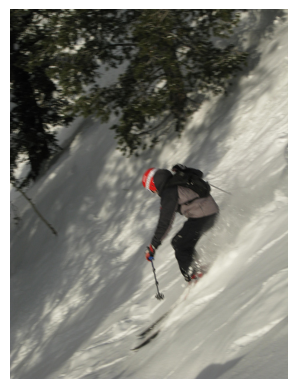

Index: 2
Ref: Example:
	Input: A dog with his tongue out running through the grass.
	Output: The dog is sticking out his tongue and looking towards me

Input: The black and white dog stands near a person holding a Frisbee.
Output: <final> The dog is looking towards the person holding the Frisbee. </final>


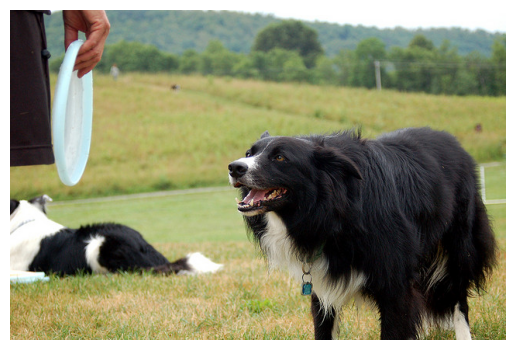

Index: 3
Ref: Example:
	Input: A cross country skier taking in the views.
	Output: A man is looking at the scenery while skiing in the mountains

Input: A plane emitting smoke stream flying over a mountain.
Output: <final> A plane is flying over the mountain. </final>


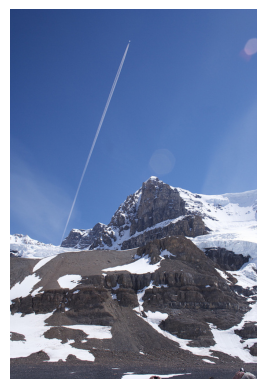

Index: 4
Ref: Example:
	Input: The baby girl is brushing her teeth while sitting on the toilet.
	Output: A small child is brushing his teeth with a toothbrush

Input: A woman wearing a necklace is brushing her teeth.
Output: <final> A woman is brushing her teeth with a toothbrush. </final>


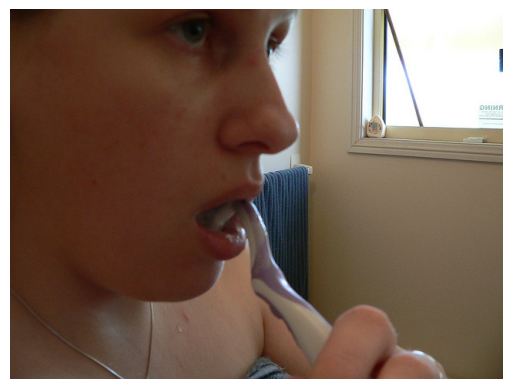

Index: 5
Ref: Example:
	Input: A man wearing a suit and tie walking down a street.
	Output: A man wearing glasses is twisting his mouth

Input: A man stands with a frown on his face.
Output: <final> The man in the suit is frowning. </final>


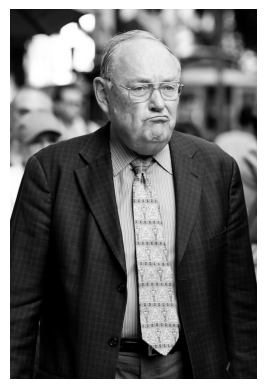

Index: 6
Ref: Example:
	Input: A man is standing outside near a dog on a chair.
	Output: A man looks down at his dog sitting on a chair

Input: A vintage photo of two men and a lama.
Output: <final> The man on the left is standing next to a lama on the street. </final>


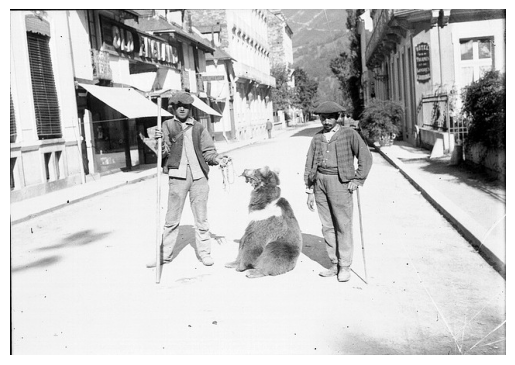

Index: 7
Ref: Example:
	Input: a woman standing on a surfboard as she rides a small wave
	Output: A woman in a black and grey wetsuit holds onto a surfboard

Input: A man is holding a surfboard and standing in the ocean.
Output: <final> A man in a black wetsuit holds onto a surfboard </final>


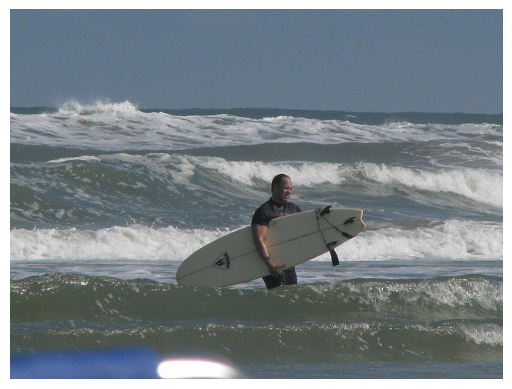

In [11]:
SHOW_INDEX = True
SHOW_REF_PROMPT = True
SHOW_INPUT_CAP = True
SHOW_OUT = True
SHOW_IMG = True

for k, o in enumerate(outputs):
    
    im_path = list(train_idx_to_cap_dict.keys())[k]

    # Print stuff
    if SHOW_INDEX:
        print('Index: ' + str(k))
    if SHOW_REF_PROMPT:
        print('Ref: ' + train_idx_to_formatted_prompt[im_path])
    if SHOW_INPUT_CAP:
        print('Input: ' + train_idx_to_cap_dict[im_path])
    if SHOW_OUT:
        print('Output: ' + o.outputs[0].text)
    
    # Read the image
    if SHOW_IMG: 
        img = mpimg.imread(im_path)
        plt.imshow(img)
        plt.axis('off')  # Turn off axis labels
        plt.show()

### Now Run Main Inference

In [12]:
BATCH_SIZE = 32

# Load LLaMA response dictionary in progress
if LOAD_IN_PROGRESS_LLAMA_DICT:
    with open(OUT_PATH, 'rb') as f:
        llama_response_dict = pickle.load(f)
    print('So far: ' + str(len(llama_response_dict)) + ' samples')
else:
    llama_response_dict = dict()    

# Loop through all data
for i in range(0, len(prompts), BATCH_SIZE):

    # Check if we already recaptioned sample 
    if i < len(llama_response_dict):
        continue
        
    # Get current batch of images and text, formatted for LLaMA 3.2
    curr_text_prompts = prompts[i:i+BATCH_SIZE]
    curr_img_paths = image_paths[i:i+BATCH_SIZE]
    curr_imgs = [Image.open(im_path) for im_path in curr_img_paths]
    curr_text_prompts_formatted = [f"<|image|><|begin_of_text|>" + j for j in curr_text_prompts]
    inputs = []
    for j in range(len(curr_imgs)):
        inputs.append({"prompt": curr_text_prompts_formatted[j], 
                        "multi_modal_data": {
                            "image": curr_imgs[j]
                        }, 
                      })

    # Generate outputs for current batch
    outputs = llm.generate(inputs, sampling_params=sampling_params)

    # Write outputs to file (done every batch to checkpoint) 
    for i, output in enumerate(outputs):
        generated_text = output.outputs[0].text
        curr_train_id = curr_img_paths[i]
        llama_response_dict[curr_train_id] = dict()
        llama_response_dict[curr_train_id]['ref_prompt'] = curr_text_prompts_formatted[i]
        llama_response_dict[curr_train_id]['full_response'] = generated_text
        llama_response_dict[curr_train_id]['parsed_response'] = extract_text_between_final_tags_v2(generated_text)

    # Write output
    with open(OUT_PATH, 'wb') as f:
        pickle.dump(llama_response_dict, f)    

INFO 05-10 12:26:18 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
INFO 05-10 12:26:18 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
INFO 05-10 12:26:18 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future release. For more details, see: https://github.com/vllm-project/vllm/issues/10114
INFO 05-10 12:26:18 preprocess.py:215] Your model uses the legacy input pipeline instead of the new multi-modal processor. Please note that the legacy pipeline will be removed in a future re

Processed prompts:  41%|████      | 13/32 [00:08<00:07,  2.53it/s, est. speed input: 365.69 toks/s, output: 24.26 toks/s]
KeyboardInterrupt

